In [19]:
# Step 1: Import Required Libraries
# Imported Pandas, NumPy, Matplotlib and Seaborn for data analysis and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

In [20]:
# uploading files
from google.colab import files

uploaded = files.upload()

Saving indian_roads_dataset.csv to indian_roads_dataset (1).csv


In [21]:
#Loading Dataset
df = pd.read_csv("indian_roads_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (20000, 24)


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [22]:
#In this section it show overview of the dataset
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [24]:
#Data Cleaning
# Remove duplicates
df.drop_duplicates(inplace=True)

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Create new columns
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month_name()

print("Cleaning Completed")

Cleaning Completed


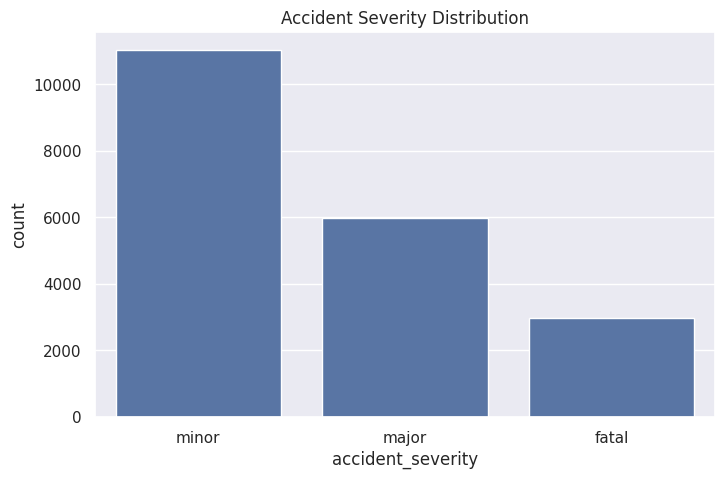

In [25]:
#accident analysis severity
#Analyzed the distribution of accident severity levels.
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="accident_severity",
    order=df["accident_severity"].value_counts().index
)

plt.title("Accident Severity Distribution")
plt.show()

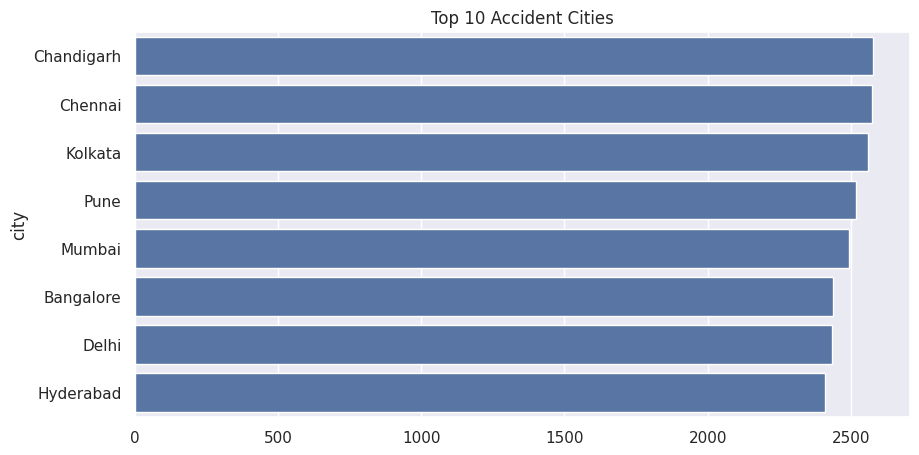

In [26]:
#Top Cities Analysis
# Identified cities with the highest number of accidents.
top_cities = df["city"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Accident Cities")
plt.show()

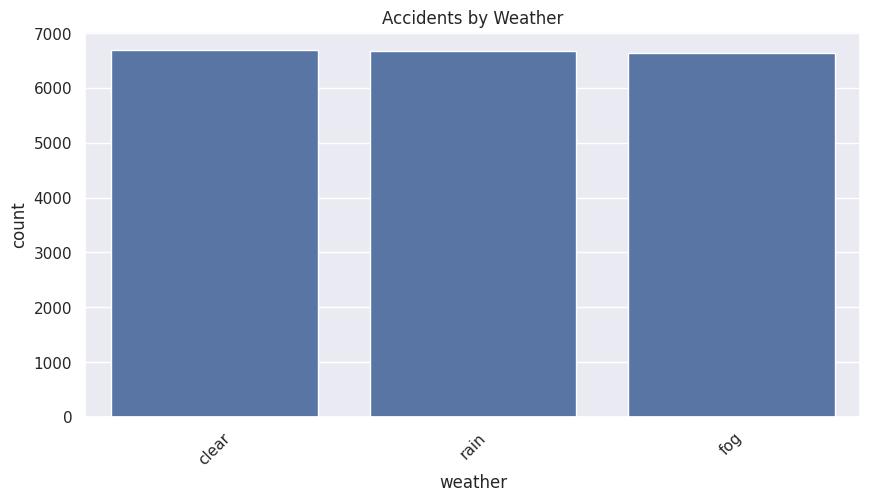

In [27]:
#Weather Analysis
# Evaluated the impact of weather conditions on accidents.
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="weather",
    order=df["weather"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Accidents by Weather")
plt.show()

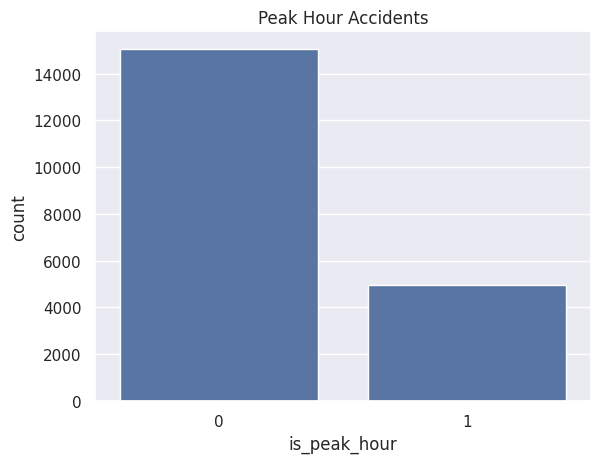

In [28]:
#Peak Hour Analysis
# Compared accident occurrences during peak and non-peak traffic hours.
sns.countplot(
    data=df,
    x="is_peak_hour"
)

plt.title("Peak Hour Accidents")
plt.show()

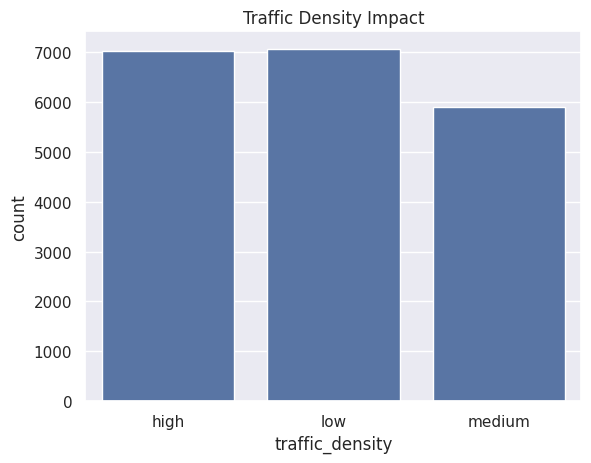

In [29]:
#traffic Density Analysis
# Studied the relationship between traffic density and accidents.
sns.countplot(
    data=df,
    x="traffic_density"
)

plt.title("Traffic Density Impact")
plt.show()

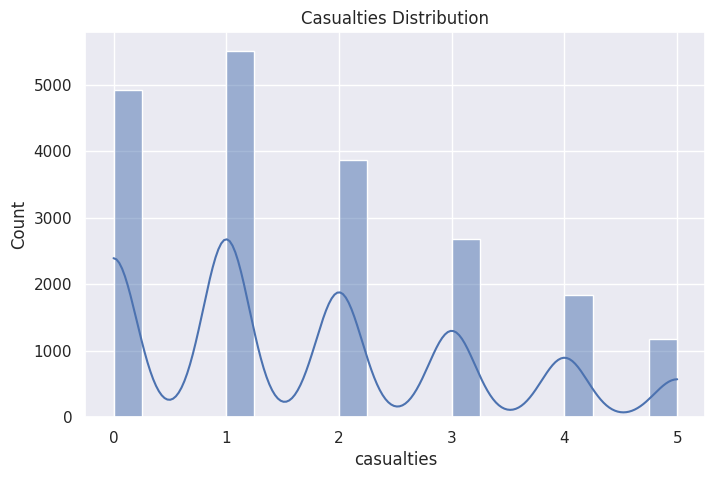

In [30]:
# Step 11: Casualties Analysis
# Visualized the distribution of casualties across accident records
plt.figure(figsize=(8,5))

sns.histplot(
    df["casualties"],
    bins=20,
    kde=True
)

plt.title("Casualties Distribution")
plt.show()

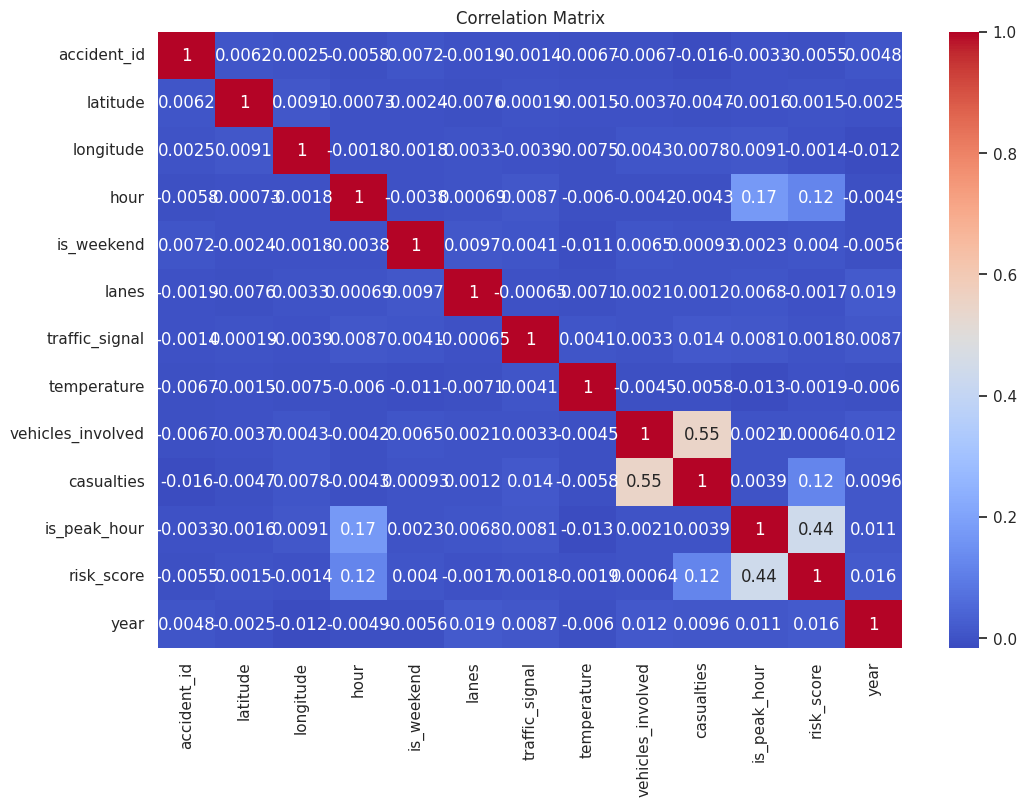

In [31]:

# Step 12: Correlation Analysis
# Generated a heatmap to identify relationships between numerical variables.
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [32]:
# Step 13: Save Cleaned Dataset
# Exported the cleaned dataset for future analysis and reporting.
df.to_csv(
    "cleaned_road_accidents.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
# Step 14: Download Dataset
# Downloaded the processed dataset for upcoming project tasks.
from google.colab import files

files.download("cleaned_road_accidents.csv")

# Conclusion
# Successfully completed data cleaning and exploratory data analysis on the road accident dataset.